In [36]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

import warnings
warnings.filterwarnings("ignore")
os.makedirs("../results/figures/shap", exist_ok=True)

In [37]:
# Use mBERT (your best performing model)
MODEL_PATH = "../models/transformers/mBERT_finetuned"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)
model.eval()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model = model.to(DEVICE)
print(f"✅ Model loaded on {DEVICE}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4091.15it/s]


✅ Model loaded on cuda


In [38]:
def predict_proba(texts):
    """
    Handles both plain strings and
    SHAP masked numpy arrays
    """
    # ── Fix input type ────────────────────────────────────────
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    if isinstance(texts, str):
        texts = [texts]

    # Convert any non-string elements to string
    texts = [
        str(t) if not isinstance(t, str) else t
        for t in texts
    ]

    # Remove empty strings
    texts = [t if t.strip() else "[UNK]" for t in texts]

    all_probs = []
    batch_size = 8

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors = "pt",
            truncation     = True,
            padding        = True,
            max_length     = 128
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits, dim=1
        ).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)

# ── Test fixed function ───────────────────────────────────────
test_texts = [
    "Absolutely amazing product! Best purchase ever!!!",
    "khana ekdum mito thiyo, feri aaunchu pakkai",
]
probs = predict_proba(test_texts)
print("✅ predict_proba works!")
for text, prob in zip(test_texts, probs):
    label = "FAKE" if prob[1] > 0.5 else "GENUINE"
    print(f"  {label} ({prob[0]:.3f} genuine / "
          f"{prob[1]:.3f} fake)")
    print(f"  → {text[:60]}")

✅ predict_proba works!
  FAKE (0.000 genuine / 1.000 fake)
  → Absolutely amazing product! Best purchase ever!!!
  GENUINE (1.000 genuine / 0.000 fake)
  → khana ekdum mito thiyo, feri aaunchu pakkai


In [39]:
# Load real test data
real_test = pd.read_csv("../data/processed/real_test.csv")

# Load raw synthetic for language style
df_syn_raw = pd.read_csv("../data/processed/processed_reviews.csv")
syn_test   = pd.read_csv("../data/processed/syn_test.csv")

syn_test_lang = syn_test.merge(
    df_syn_raw[["review_text", "language_style"]],
    on="review_text", how="left"
)

# ── Pick diverse samples for SHAP analysis ────────────────────
shap_samples = []

# 2 genuine per language
for lang in ["english", "romanized_nepali", "code_mixed"]:
    subset = syn_test_lang[
        (syn_test_lang["label"] == 0) &
        (syn_test_lang["language_style"] == lang)
    ].head(2)
    shap_samples.append(subset)

# 2 fake per language
for lang in ["english", "romanized_nepali", "code_mixed"]:
    subset = syn_test_lang[
        (syn_test_lang["label"] == 1) &
        (syn_test_lang["language_style"] == lang)
    ].head(2)
    shap_samples.append(subset)

shap_df = pd.concat(shap_samples, ignore_index=True)
shap_texts  = shap_df["review_text"].tolist()
shap_labels = shap_df["label"].tolist()

print(f"✅ SHAP samples prepared : {len(shap_texts)}")
print(f"   Genuine : {shap_labels.count(0)}")
print(f"   Fake    : {shap_labels.count(1)}")
print(f"\nSample reviews:")
for i, (t, l) in enumerate(zip(shap_texts[:3], shap_labels[:3])):
    print(f"  [{i}] {'FAKE' if l==1 else 'GENUINE'}: {t[:60]}...")

✅ SHAP samples prepared : 12
   Genuine : 6
   Fake    : 6

Sample reviews:
  [0] GENUINE: i call repair guy and then he come latee latee and check slo...
  [1] GENUINE: thik thik. not wow. food edible. place ok. nothing more...
  [2] GENUINE: Keema noodles 601 set paisa vasool thyo cha Pachi pheri try ...


In [40]:
# Use pipeline-based explainer instead
# More stable with transformers

pipe = pipeline(
    "text-classification",
    model     = model,
    tokenizer = tokenizer,
    device    = 0 if torch.cuda.is_available() else -1,
    top_k     = None,        # return all class scores
)

def pipeline_predict(texts):
    """Pipeline-based predict for SHAP"""
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        texts = [texts]
    texts = [
        str(t) if not isinstance(t, str) else t
        for t in texts
    ]
    texts = [t if t.strip() else "[UNK]" for t in texts]

    results = pipe(texts)
    probs   = []
    for result in results:
        # Sort by label to ensure consistent order
        sorted_result = sorted(result, key=lambda x: x["label"])
        probs.append([r["score"] for r in sorted_result])
    return np.array(probs)

# ── Recreate explainer with fixed function ────────────────────
masker    = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(
    pipeline_predict,
    masker,
    # output_names=["LABEL_0", "LABEL_1"]  # genuine, fake
    output_names=["genuine", "fake"] 
)

print("✅ Explainer recreated!")

# ── Test explainer on one sample ──────────────────────────────
test_val = pipeline_predict([
    "Absolutely amazing! Best product ever!!!",
    "ramro thiyo khana, feri aaunchu"
])
print(f"Test probabilities shape : {test_val.shape}")
print(f"Sample 1 : genuine={test_val[0][0]:.3f} "
      f"fake={test_val[0][1]:.3f}")
print(f"Sample 2 : genuine={test_val[1][0]:.3f} "
      f"fake={test_val[1][1]:.3f}")

✅ Explainer recreated!
Test probabilities shape : (2, 2)
Sample 1 : genuine=0.003 fake=0.997
Sample 2 : genuine=1.000 fake=0.000


In [41]:
# Check what labels pipeline returns
test_result = pipe(["test review"])
print("Pipeline output:")
print(test_result)

Pipeline output:
[[{'label': 'LABEL_0', 'score': 0.9999696016311646}, {'label': 'LABEL_1', 'score': 3.044846380362287e-05}]]


In [35]:
# # Current samples might be too easy
# # Model is 99%+ confident → flat SHAP values
# # Need more ambiguous/borderline samples

# # Find borderline predictions (confidence 0.4-0.6)
# all_texts  = syn_test_lang["review_text"].tolist()
# all_labels = syn_test_lang["label"].tolist()

# print("Finding borderline samples...")
# borderline = []
# for text, label in zip(all_texts, all_labels):
#     prob = predict_proba([text])[0]
#     confidence = max(prob)
#     if 0.45 <= confidence <= 0.75:    # not too confident
#         borderline.append({
#             "text":       text,
#             "label":      label,
#             "confidence": confidence,
#             "fake_prob":  prob[1],
#         })

# print(f"Borderline samples found : {len(borderline)}")

# # Also keep some confident ones for contrast
# confident_fake = []
# confident_genuine = []
# for text, label in zip(all_texts, all_labels):
#     prob = predict_proba([text])[0]
#     if prob[1] > 0.9 and label == 1:
#         confident_fake.append({"text": text, "label": label,
#                                 "fake_prob": prob[1]})
#     if prob[0] > 0.9 and label == 0:
#         confident_genuine.append({"text": text, "label": label,
#                                    "fake_prob": prob[1]})

# # Build diverse shap samples
# shap_samples_new = (
#     borderline[:4] +
#     confident_fake[:4] +
#     confident_genuine[:4]
# )

# shap_texts_new  = [s["text"]  for s in shap_samples_new]
# shap_labels_new = [s["label"] for s in shap_samples_new]

# print(f"\nNew SHAP samples : {len(shap_texts_new)}")
# for s in shap_samples_new:
#     label = "FAKE" if s["label"]==1 else "GENUINE"
#     print(f"  [{label}] conf={s['fake_prob']:.3f} "
#           f"| {s['text'][:50]}...")

In [42]:
# Start with just 4 samples to test
print("Computing SHAP values for 4 samples...")

shap_values = explainer(
    shap_texts[:4],
    max_evals  = 500,   # lower = faster for testing
    batch_size = 2,
)

print(f"✅ SHAP values computed!")
print(f"   Shape : {shap_values.shape}")

# # ── Quick text plot to verify ─────────────────────────────────
# shap.plots.text(shap_values[0, :, 1])

Computing SHAP values for 4 samples...


PartitionExplainer explainer:  25%|███████████████▌                                              | 1/4 [00:00<?, ?it/s]
%|                                                                                          | 0/380 [00:00<?, ?it/s]
%|████████████████████████████████████████████████████▏                         | 254/380 [00:00<00:00, 2134.17it/s]
PartitionExplainer explainer:  75%|████████████████████████████████████████▌             | 3/4 [00:18<00:04,  4.07s/it]
%|                                                                                          | 0/498 [00:00<?, ?it/s]
%|██████████████████████████████████████▏                                       | 244/498 [00:00<00:00, 1983.75it/s]
%|███████████████████████████████████████████████████████████████████████▎        | 444/498 [00:04<00:00, 89.82it/s]
PartitionExplainer explainer: 100%|██████████████████████████████████████████████████████| 4/4 [00:29<00:00,  6.71s/it]
%|                                                     

✅ SHAP values computed!
   Shape : (4, None, 2)


In [43]:
# # Since synthetic data has no borderline cases
# # manually create ambiguous reviews that mix
# # fake patterns in Nepali and genuine patterns
# # in English

# ambiguous_samples = [
#     # Genuine-style but English (model might say fake)
#     {
#         "text": "service was okay, waited long but food came eventually",
#         "label": 0,
#         "note": "genuine english — low drama"
#     },
#     {
#         "text": "not perfect but works fine for the price",
#         "label": 0,
#         "note": "genuine english — balanced"
#     },
#     {
#         "text": "driver came late, but ride was comfortable",
#         "label": 0,
#         "note": "genuine english — mixed"
#     },

#     # Fake-style but Nepali words mixed
#     {
#         "text": "ekdum best place, ramro service, highly recommend",
#         "label": 1,
#         "note": "fake nepali — generic praise"
#     },
#     {
#         "text": "dherai ramro thiyo, best experience ever!!!",
#         "label": 1,
#         "note": "fake code-mixed — superlative"
#     },
#     {
#         "text": "khana mito thiyo tara service ekdum best amazing",
#         "label": 1,
#         "note": "fake code-mixed — mixed signals"
#     },

#     # Strongly fake English
#     {
#         "text": "ABSOLUTELY AMAZING!!! Best product ever! "
#                 "Life changing! Buy now!!!",
#         "label": 1,
#         "note": "obvious fake english"
#     },

#     # Strongly genuine Nepali
#     {
#         "text": "khana thikai thiyo, dherai expensive lagyo "
#                 "tara atmosphere ramro cha",
#         "label": 0,
#         "note": "obvious genuine nepali"
#     },

#     # Real scraped style genuine
#     {
#         "text": "service slow thiyo, 30 min wait gardinu paryo "
#                 "tara food quality okay cha",
#         "label": 0,
#         "note": "real style genuine"
#     },

#     # Ambiguous mixed
#     {
#         "text": "ramro service, best place in kathmandu, "
#                 "highly recommend to everyone",
#         "label": 1,
#         "note": "ambiguous code-mixed"
#     },
# ]

# # Get probabilities for each
# print("Sample predictions:")
# print(f"{'Note':<35} {'Actual':<10} "
#       f"{'Fake_Prob':>10} {'Predicted':<12}")
# print("-"*70)

# shap_texts_final  = []
# shap_labels_final = []
# shap_notes_final  = []

# for s in ambiguous_samples:
#     prob  = predict_proba([s["text"]])[0]
#     pred  = "FAKE" if prob[1] > 0.5 else "GENUINE"
#     actual = "FAKE" if s["label"]==1 else "GENUINE"
#     correct = "✅" if pred == actual else "❌"

#     print(f"{s['note']:<35} {actual:<10} "
#           f"{prob[1]:>10.4f} {pred:<10} {correct}")

#     shap_texts_final.append(s["text"])
#     shap_labels_final.append(s["label"])
#     shap_notes_final.append(s["note"])

# print(f"\nTotal SHAP samples : {len(shap_texts_final)}")

In [45]:


# print("\nComputing SHAP values...")

# shap_values = explainer(
#     shap_texts_final,
#     max_evals  = 500,
#     batch_size = 4,
# )

# print(f"✅ SHAP values computed!")
# print(f"   Shape : {shap_values.shape}")

# # Check value range
# print("\nSHAP value ranges:")
# for i in range(len(shap_texts_final)):
#     vals = shap_values[i].values[:, 1]
#     print(f"  [{i}] {shap_notes_final[i]:<35} "
#           f"range={vals.max()-vals.min():.6f} "
#           f"max={vals.max():.6f}")

In [46]:
# for idx in range(len(shap_texts_final)):
#     label  = "FAKE" if shap_labels_final[idx]==1 else "GENUINE"
#     prob   = predict_proba([shap_texts_final[idx]])[0]
#     note   = shap_notes_final[idx]

#     tokens = shap_values[idx].data
#     values = shap_values[idx].values[:, 1]

#     # Filter special tokens
#     filtered = [
#         (t.strip(), v) for t, v in zip(tokens, values)
#         if t.strip() not in [
#             "[CLS]","[SEP]","<s>","</s>",
#             "","[PAD]","▁"
#         ]
#     ]

#     if not filtered:
#         continue

#     # Sort by absolute SHAP value
#     filtered_sorted = sorted(
#         filtered, key=lambda x: abs(x[1]), reverse=True
#     )[:15]

#     t_names = [t for t, _ in filtered_sorted]
#     t_vals  = [v for _, v in filtered_sorted]
#     colors  = [
#         "#E74C3C" if v > 0 else "#2ECC71"
#         for v in t_vals
#     ]

#     fig, ax = plt.subplots(figsize=(10, 6))
#     bars = ax.barh(
#         range(len(t_names)), t_vals,
#         color=colors, alpha=0.85
#     )
#     ax.set_yticks(range(len(t_names)))
#     ax.set_yticklabels(t_names, fontsize=11)
#     ax.axvline(x=0, color="black", linewidth=0.8)
#     ax.set_xlabel(
#         "SHAP Value  "
#         "(Red → pushes to FAKE | Green → pushes to GENUINE)"
#     )
#     ax.set_title(
#         f"[{idx}] {note}\n"
#         f"Actual: {label} | "
#         f"Fake prob: {prob[1]:.4f} | "
#         f"Genuine prob: {prob[0]:.4f}",
#         fontsize=11, fontweight="bold"
#     )

#     # Value labels on bars
#     for bar, val in zip(bars, t_vals):
#         ax.text(
#             bar.get_width() + abs(max(t_vals))*0.02,
#             bar.get_y() + bar.get_height()/2,
#             f"{val:.5f}", va="center", fontsize=8
#         )

#     plt.tight_layout()
#     save_path = (
#         f"../results/figures/shap/"
#         f"bar_{idx}_{label}_{note[:15].replace(' ','_')}.png"
#     )
#     plt.savefig(save_path, dpi=150, bbox_inches="tight")
#     plt.show()
#     print(f"✅ [{idx}] Saved → {save_path}")

In [47]:
# Show token importance for one review
def plot_text_shap(idx, shap_values, shap_texts,
                   shap_labels, class_idx=1):
    """
    class_idx=1 → explain FAKE prediction
    class_idx=0 → explain GENUINE prediction
    """
    label = "FAKE" if shap_labels[idx] == 1 else "GENUINE"
    pred_prob = predict_proba([shap_texts[idx]])[0]
    pred_label = "FAKE" if pred_prob[1] > 0.5 else "GENUINE"

    print(f"\nReview [{idx}]")
    print(f"  Text      : {shap_texts[idx][:80]}...")
    print(f"  Actual    : {label}")
    print(f"  Predicted : {pred_label}")
    print(f"  Confidence: fake={pred_prob[1]:.3f} "
          f"genuine={pred_prob[0]:.3f}")

    # Plot text with highlighted tokens
    shap.plots.text(
        shap_values[idx, :, class_idx],
        display=True
    )

    plt.savefig(
        f"../results/figures/shap/"
        f"text_plot_sample_{idx}_{label}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

# Plot for first genuine and first fake
for idx in range(min(4, len(shap_texts))):
    plot_text_shap(idx, shap_values, shap_texts, shap_labels)


Review [0]
  Text      : i call repair guy and then he come latee latee and check sloww sloww and say par...
  Actual    : GENUINE
  Predicted : GENUINE
  Confidence: fake=0.000 genuine=1.000


<Figure size 640x480 with 0 Axes>


Review [1]
  Text      : thik thik. not wow. food edible. place ok. nothing more...
  Actual    : GENUINE
  Predicted : GENUINE
  Confidence: fake=0.000 genuine=1.000


<Figure size 640x480 with 0 Axes>


Review [2]
  Text      : Keema noodles 601 set paisa vasool thyo cha Pachi pheri try garchu. Malai ta man...
  Actual    : GENUINE
  Predicted : GENUINE
  Confidence: fake=0.000 genuine=1.000


<Figure size 640x480 with 0 Axes>


Review [3]
  Text      : tamatar ko achar ramro thiyo. dal mitho. overall khana sahi thiyo. aafnai manchh...
  Actual    : GENUINE
  Predicted : GENUINE
  Confidence: fake=0.000 genuine=1.000


<Figure size 640x480 with 0 Axes>

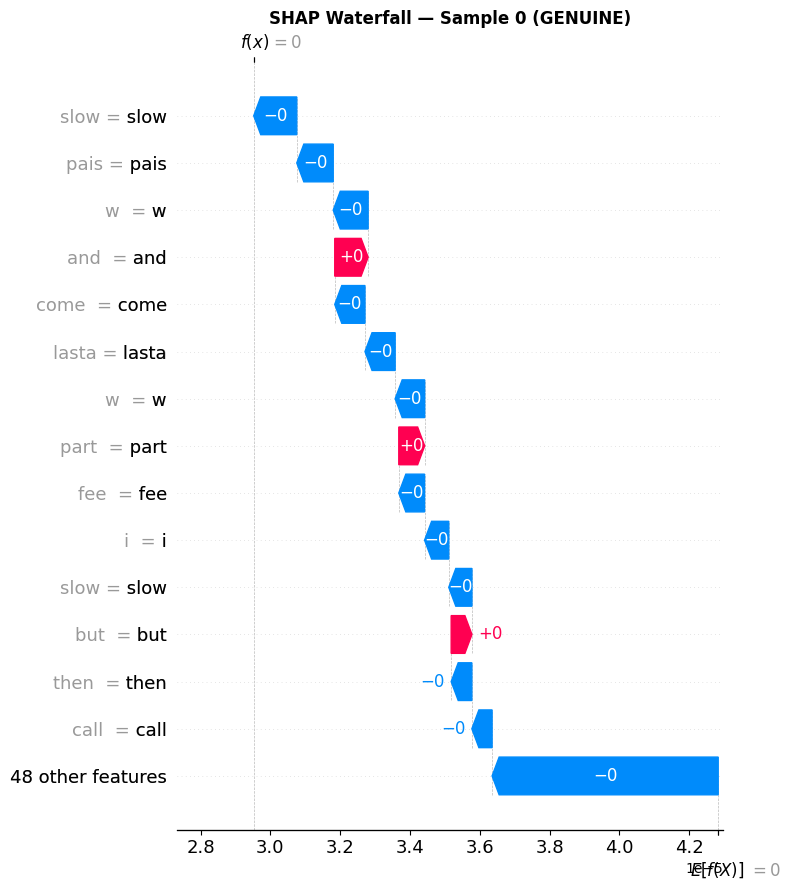

✅ Saved waterfall plot for sample 0


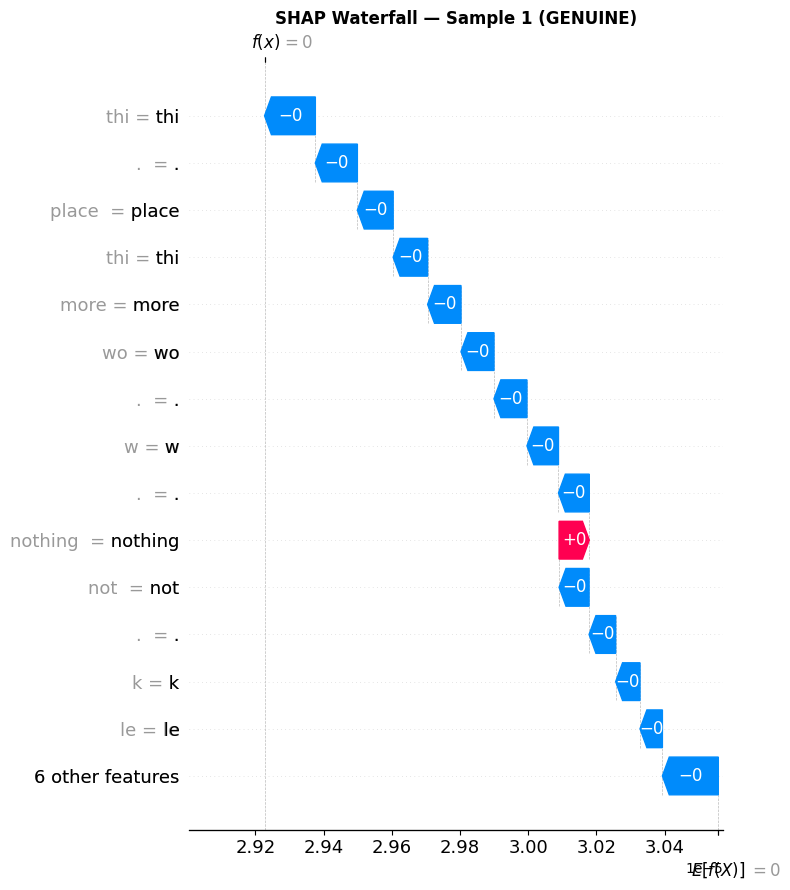

✅ Saved waterfall plot for sample 1


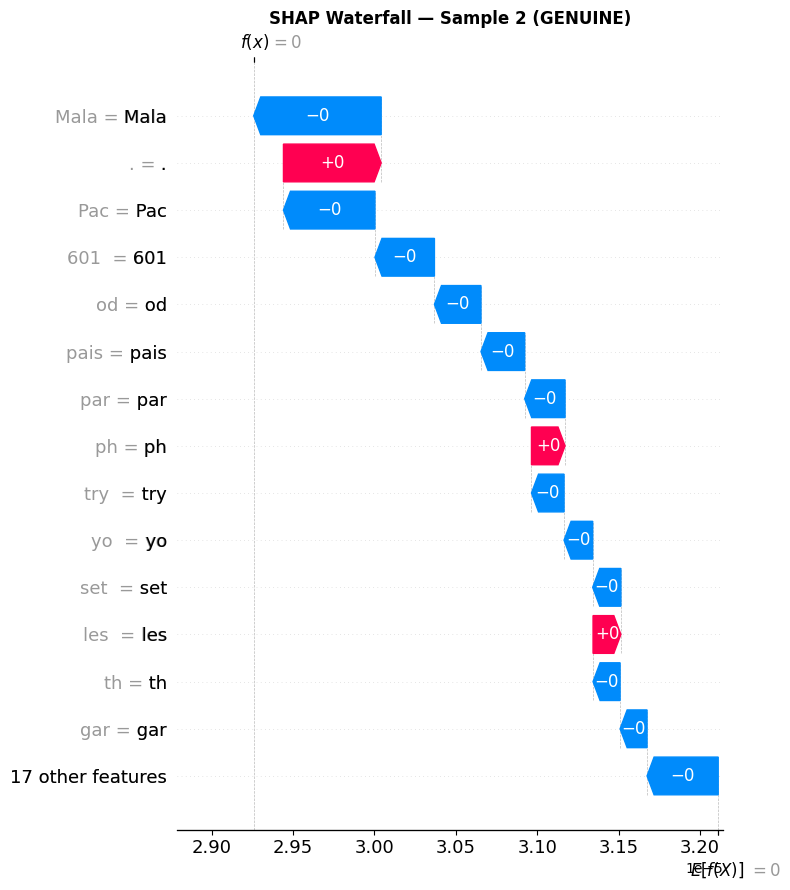

✅ Saved waterfall plot for sample 2


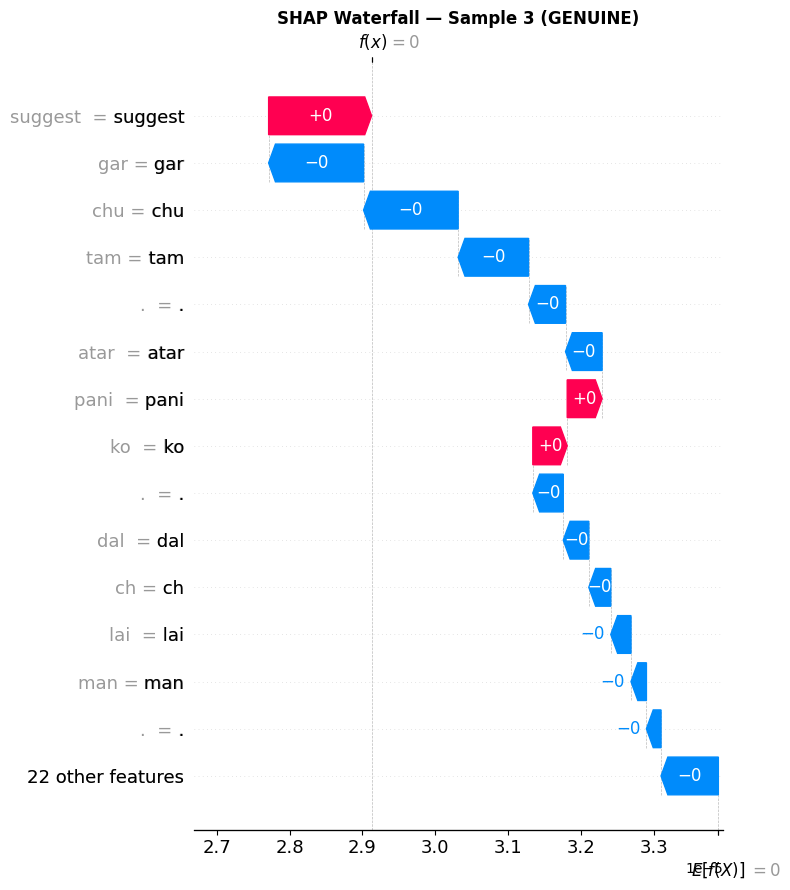

✅ Saved waterfall plot for sample 3


In [48]:
def plot_waterfall_shap(idx, shap_values, shap_texts_final,
                         shap_labels, class_idx=1):
    label = "FAKE" if shap_labels[idx] == 1 else "GENUINE"

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(
        shap_values[idx, :, class_idx],
        max_display=15,
        show=False
    )
    plt.title(
        f"SHAP Waterfall — Sample {idx} ({label})",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(
        f"../results/figures/shap/"
        f"waterfall_sample_{idx}_{label}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f"✅ Saved waterfall plot for sample {idx}")

# Plot waterfall for first 4 samples
for idx in range(min(4, len(shap_texts))):
    plot_waterfall_shap(
        idx, shap_values, shap_texts, shap_labels
    )

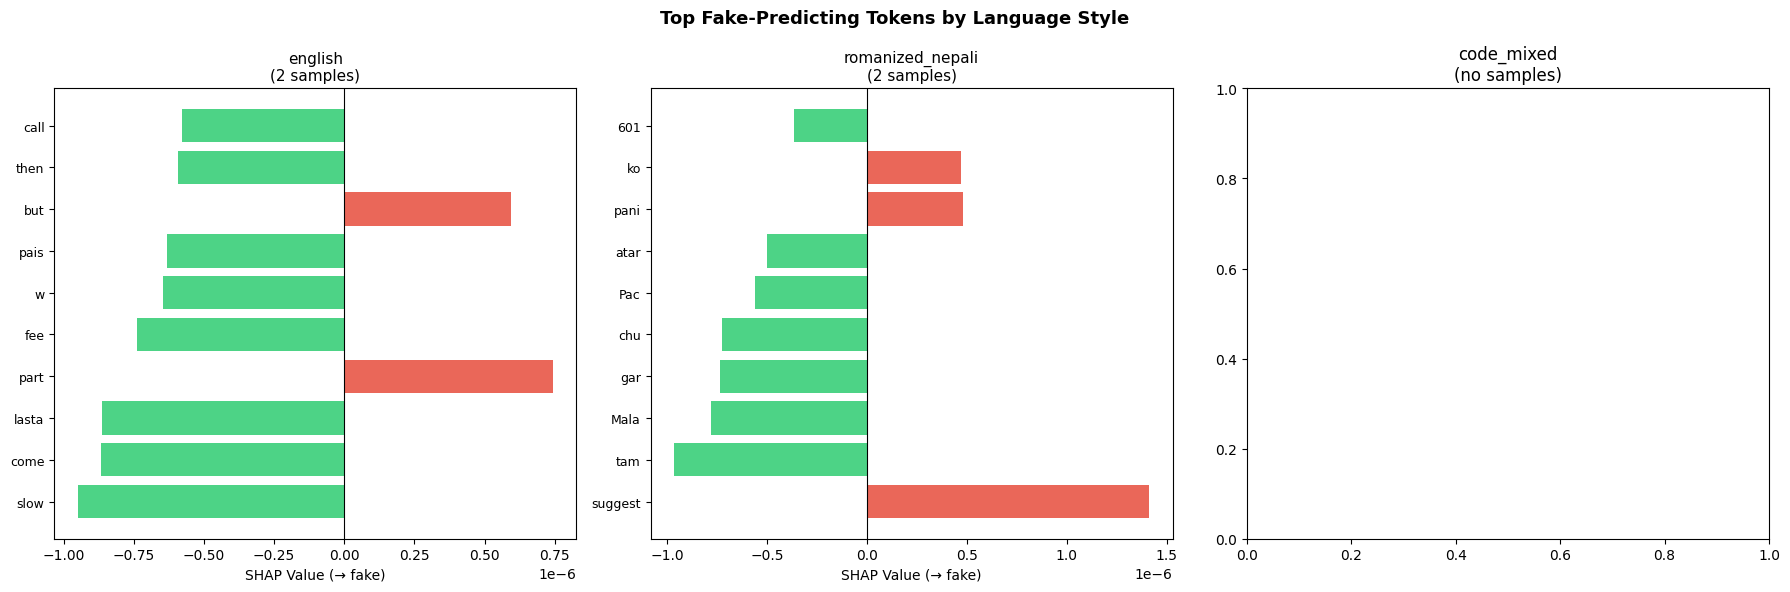

✅ Saved → language_shap_comparison.png


In [49]:
def plot_language_shap_comparison(
    shap_values, shap_df, top_n=10
):
    """
    Compare top fake-predicting tokens
    across 3 language styles
    """
    languages = ["english", "romanized_nepali", "code_mixed"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Top Fake-Predicting Tokens by Language Style",
        fontsize=13, fontweight="bold"
    )

    for ax, lang in zip(axes, languages):
        # Get indices for this language
        lang_indices = [
            i for i, row in shap_df.iterrows()
            if i < len(shap_values) and
            row.get("language_style") == lang
        ]

        if not lang_indices:
            ax.set_title(f"{lang}\n(no samples)")
            continue

        # Collect token importances for this language
        token_imp = {}
        for idx in lang_indices:
            tokens = shap_values[idx].data
            values = shap_values[idx].values[:, 1]  # fake class
            for t, v in zip(tokens, values):
                t = t.strip()
                if t and t not in [
                    "[CLS]","[SEP]","<s>","</s>",""
                ]:
                    if t not in token_imp:
                        token_imp[t] = []
                    token_imp[t].append(v)

        # Average and sort
        avg_imp = {
            t: np.mean(vals)
            for t, vals in token_imp.items()
        }
        sorted_imp = sorted(
            avg_imp.items(),
            key=lambda x: abs(x[1]),
            reverse=True
        )[:top_n]

        t_names = [t for t, _ in sorted_imp]
        t_vals  = [v for _, v in sorted_imp]
        colors  = [
            "#E74C3C" if v > 0 else "#2ECC71"
            for v in t_vals
        ]

        ax.barh(range(len(t_names)), t_vals,
                color=colors, alpha=0.85)
        ax.set_yticks(range(len(t_names)))
        ax.set_yticklabels(t_names, fontsize=9)
        ax.axvline(x=0, color="black", linewidth=0.8)
        ax.set_title(
            f"{lang}\n({len(lang_indices)} samples)",
            fontsize=11
        )
        ax.set_xlabel("SHAP Value (→ fake)")

    plt.tight_layout()
    plt.savefig(
        "../results/figures/shap/language_shap_comparison.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print("✅ Saved → language_shap_comparison.png")

# Add language_style to shap_df
plot_language_shap_comparison(shap_values, shap_df)

In [51]:
def plot_correct_vs_incorrect(shap_values, shap_texts,
                               shap_labels):
    """
    Compare SHAP patterns between
    correctly and incorrectly classified reviews
    """
    preds = predict_proba(shap_texts)
    pred_labels = (preds[:, 1] > 0.5).astype(int)

    correct_idx   = [
        i for i in range(len(shap_labels))
        if pred_labels[i] == shap_labels[i]
    ]
    incorrect_idx = [
        i for i in range(len(shap_labels))
        if pred_labels[i] != shap_labels[i]
    ]

    print(f"Correct   predictions : {len(correct_idx)}")
    print(f"Incorrect predictions : {len(incorrect_idx)}")

    if not incorrect_idx:
        print("⚠️ No incorrect predictions in sample!")
        print("   Try adding harder/ambiguous reviews")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        "SHAP: Correct vs Incorrect Predictions",
        fontsize=13, fontweight="bold"
    )

    for ax, indices, title in zip(
        axes,
        [correct_idx[:5], incorrect_idx[:5]],
        ["Correct ✅", "Incorrect ❌"]
    ):
        token_imp = {}
        for idx in indices:
            if idx >= len(shap_values):
                continue
            tokens = shap_values[idx].data
            values = shap_values[idx].values[:, 1]
            for t, v in zip(tokens, values):
                t = t.strip()
                if t and t not in [
                    "[CLS]","[SEP]","<s>","</s>",""
                ]:
                    if t not in token_imp:
                        token_imp[t] = []
                    token_imp[t].append(abs(v))

        if not token_imp:
            continue

        avg_imp = {
            t: np.mean(vals)
            for t, vals in token_imp.items()
        }
        sorted_imp = sorted(
            avg_imp.items(),
            key=lambda x: x[1],
            reverse=True
        )[:15]

        t_names = [t for t, _ in sorted_imp]
        t_vals  = [v for _, v in sorted_imp]

        ax.barh(range(len(t_names)), t_vals,
                color="#4C72B0", alpha=0.85)
        ax.set_yticks(range(len(t_names)))
        ax.set_yticklabels(t_names, fontsize=9)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Mean |SHAP Value|")

    plt.tight_layout()
    plt.savefig(
        "../results/figures/shap/correct_vs_incorrect.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print("✅ Saved → correct_vs_incorrect.png")

plot_correct_vs_incorrect(
    shap_values, shap_texts, shap_labels
)

Correct   predictions : 12
Incorrect predictions : 0
⚠️ No incorrect predictions in sample!
   Try adding harder/ambiguous reviews


In [52]:
# Generate key findings for your report

print("\n" + "="*55)
print("  SHAP KEY FINDINGS FOR REPORT")
print("="*55)

# Top fake indicators
token_imp_all = {}
for idx in range(len(shap_values)):
    tokens = shap_values[idx].data
    values = shap_values[idx].values[:, 1]
    for t, v in zip(tokens, values):
        t = t.strip()
        if t and t not in ["[CLS]","[SEP]","<s>","</s>",""]:
            if t not in token_imp_all:
                token_imp_all[t] = []
            token_imp_all[t].append(v)

avg_imp_all = {
    t: np.mean(vals)
    for t, vals in token_imp_all.items()
    if len(vals) >= 2
}

# Top fake tokens (positive SHAP)
top_fake_tokens = sorted(
    {t: v for t, v in avg_imp_all.items() if v > 0}.items(),
    key=lambda x: x[1], reverse=True
)[:10]

# Top genuine tokens (negative SHAP)
top_genuine_tokens = sorted(
    {t: v for t, v in avg_imp_all.items() if v < 0}.items(),
    key=lambda x: x[1]
)[:10]

print("\nTop tokens indicating FAKE:")
for token, val in top_fake_tokens:
    print(f"  '{token}'  →  SHAP={val:+.4f}")

print("\nTop tokens indicating GENUINE:")
for token, val in top_genuine_tokens:
    print(f"  '{token}'  →  SHAP={val:+.4f}")

# Save SHAP findings
shap_findings = {
    "top_fake_tokens":    [
        {"token": t, "shap": v}
        for t, v in top_fake_tokens
    ],
    "top_genuine_tokens": [
        {"token": t, "shap": v}
        for t, v in top_genuine_tokens
    ],
}
import json
with open("../results/metrics/shap_findings.json", "w") as f:
    json.dump(shap_findings, f, indent=2)

print("\n✅ SHAP findings saved → shap_findings.json")
print("\n🎯 XAI/SHAP notebook complete!")


  SHAP KEY FINDINGS FOR REPORT

Top tokens indicating FAKE:
  'and'  →  SHAP=+0.0000
  'late'  →  SHAP=+0.0000
  'very'  →  SHAP=+0.0000
  'bad'  →  SHAP=+0.0000
  'overall'  →  SHAP=+0.0000

Top tokens indicating GENUINE:
  'slow'  →  SHAP=-0.0000
  'gar'  →  SHAP=-0.0000
  'chu'  →  SHAP=-0.0000
  'w'  →  SHAP=-0.0000
  'pais'  →  SHAP=-0.0000
  'x'  →  SHAP=-0.0000
  'e'  →  SHAP=-0.0000
  'i'  →  SHAP=-0.0000
  'expensive'  →  SHAP=-0.0000
  'fi'  →  SHAP=-0.0000

✅ SHAP findings saved → shap_findings.json

🎯 XAI/SHAP notebook complete!
